# 05 — Analisi e Visualizzazione dei Risultati

Notebook per analizzare i risultati del notebook 04 e produrre i grafici e le tabelle da usare nella relazione finale.

**Domanda di ricerca centrale**: la scelta del calibration dataset (Random / Mixed / Code) fa
differenza sull'accuratezza (pass@1) del modello quantizzato, e questa differenza si accentua a
bit più bassi?

## 1. Setup e caricamento dei dati

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "../results"
FIGURES_DIR = f"{RESULTS_DIR}/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

df_raw = pd.read_csv(f"{RESULTS_DIR}/pass_at_1_raw.csv")
pivot = pd.read_csv(f"{RESULTS_DIR}/pass_at_1_summary.csv", index_col="calibration")

print("=== Dati grezzi (tutti i 13 modelli) ===")
print(df_raw)

print("\n=== Tabella pivot (calibration x livello) ===")
print(pivot)

Matplotlib is building the font cache; this may take a moment.


=== Dati grezzi (tutti i 13 modelli) ===
            model    pass@1 status
0    baseline-f16  0.390244     OK
1     random-Q8_0  0.378049     OK
2   random-Q4_K_M  0.341463     OK
3   random-Q3_K_M  0.365854     OK
4     random-Q2_K  0.213415     OK
5      mixed-Q8_0  0.378049     OK
6    mixed-Q4_K_M  0.317073     OK
7    mixed-Q3_K_M  0.353659     OK
8      mixed-Q2_K  0.213415     OK
9       code-Q8_0  0.378049     OK
10    code-Q4_K_M  0.341463     OK
11    code-Q3_K_M  0.353659     OK
12      code-Q2_K  0.207317     OK

=== Tabella pivot (calibration x livello) ===
                 Q8_0    Q4_K_M    Q3_K_M      Q2_K
calibration                                        
random       0.378049  0.341463  0.365854  0.213415
mixed        0.378049  0.317073  0.353659  0.213415
code         0.378049  0.341463  0.353659  0.207317


## 2. Preparazione dei dati per i grafici

Mappiamo ogni livello di quantizzazione al numero approssimativo di bit, così da poter tracciare
un asse X numerico coerente (8, 4, 3, 2), e recuperiamo il valore della baseline fp16 come
riferimento orizzontale.

In [3]:
BITS_MAP = {"Q8_0": 8, "Q4_K_M": 4, "Q3_K_M": 3, "Q2_K": 2}
QUANT_LEVELS = ["Q8_0", "Q4_K_M", "Q3_K_M", "Q2_K"]
CALIBRATIONS = ["random", "mixed", "code"]

baseline_row = df_raw[df_raw["model"] == "baseline-f16"]
baseline_pass1 = float(baseline_row["pass@1"].values[0])

print(f"Baseline fp16: pass@1 = {baseline_pass1:.4f}")

bits_x = [BITS_MAP[level] for level in QUANT_LEVELS]
print("Asse X (bit):", bits_x)

Baseline fp16: pass@1 = 0.3902
Asse X (bit): [8, 4, 3, 2]


## 3. Grafico principale — pass@1 vs livello di bit

Una linea per calibration dataset, più una linea orizzontale
tratteggiata per la baseline fp16 come riferimento. L'asse X va da 8 bit (quasi lossless) a 2 bit
(compressione estrema), quindi leggerlo da destra a sinistra corrisponde a "quantizzazione via via
più aggressiva".

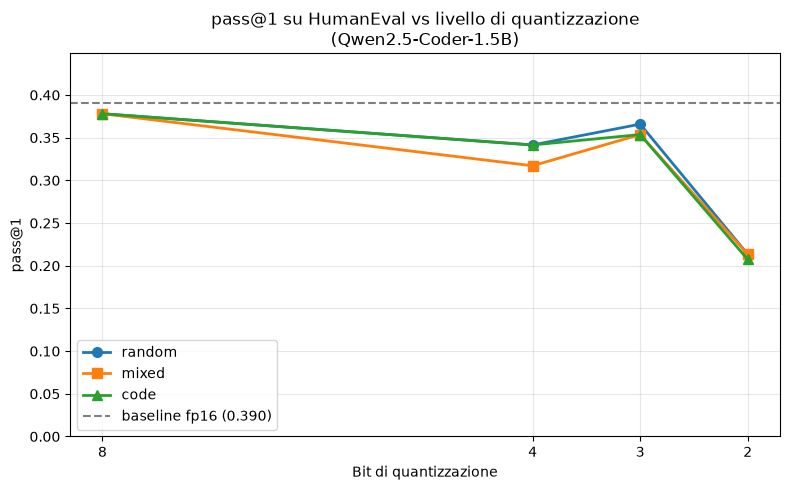

Grafico salvato in: ../results/figures/pass_at_1_vs_bits.png


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = {"random": "tab:blue", "mixed": "tab:orange", "code": "tab:green"}
markers = {"random": "o", "mixed": "s", "code": "^"}

for calib in CALIBRATIONS:
    y_values = [pivot.loc[calib, level] for level in QUANT_LEVELS]
    ax.plot(
        bits_x, y_values,
        marker=markers[calib], color=colors[calib],
        label=calib, linewidth=2, markersize=7,
    )

ax.axhline(
    baseline_pass1, color="gray", linestyle="--", linewidth=1.5,
    label=f"baseline fp16 ({baseline_pass1:.3f})",
)

ax.set_xlabel("Bit di quantizzazione")
ax.set_ylabel("pass@1")
ax.set_title("pass@1 su HumanEval vs livello di quantizzazione\n(Qwen2.5-Coder-1.5B)")
ax.set_xticks(bits_x)
ax.invert_xaxis()  # da 8 bit (sinistra) a 2 bit (destra): quantizzazione via via più aggressiva
ax.set_ylim(0, max(baseline_pass1, pivot.values.max()) * 1.15)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = f"{FIGURES_DIR}/pass_at_1_vs_bits.png"
plt.savefig(fig_path, dpi=150)
plt.show()

print(f"Grafico salvato in: {fig_path}")

## 4. Tabella di degradazione rispetto alla baseline

Calcoliamo, per ciascuna cella della tabella pivot, la perdita assoluta (punti percentuali) e
relativa (%) rispetto alla baseline fp16. Utile per quantificare "quanto costa" la quantizzazione
a ciascun livello, indipendentemente dal calibration dataset.

In [5]:
degradation_abs = (pivot - baseline_pass1) * 100  # in punti percentuali
degradation_rel = (pivot - baseline_pass1) / baseline_pass1 * 100  # in percentuale relativa

print("=== Degradazione assoluta rispetto alla baseline (punti percentuali) ===")
print(degradation_abs.round(2))

print("\n=== Degradazione relativa rispetto alla baseline (%) ===")
print(degradation_rel.round(1))

degradation_abs.to_csv(f"{RESULTS_DIR}/degradation_absolute_pp.csv")
degradation_rel.to_csv(f"{RESULTS_DIR}/degradation_relative_pct.csv")

=== Degradazione assoluta rispetto alla baseline (punti percentuali) ===
             Q8_0  Q4_K_M  Q3_K_M   Q2_K
calibration                             
random      -1.22   -4.88   -2.44 -17.68
mixed       -1.22   -7.32   -3.66 -17.68
code        -1.22   -4.88   -3.66 -18.29

=== Degradazione relativa rispetto alla baseline (%) ===
             Q8_0  Q4_K_M  Q3_K_M  Q2_K
calibration                            
random       -3.1   -12.5    -6.3 -45.3
mixed        -3.1   -18.8    -9.4 -45.3
code         -3.1   -12.5    -9.4 -46.9


## 5. Grafico a barre raggruppate (vista alternativa)

Stessa informazione del grafico a linee, ma come barre raggruppate per livello di quantizzazione:
utile per confrontare visivamente le tre calibration a parità di livello di bit.

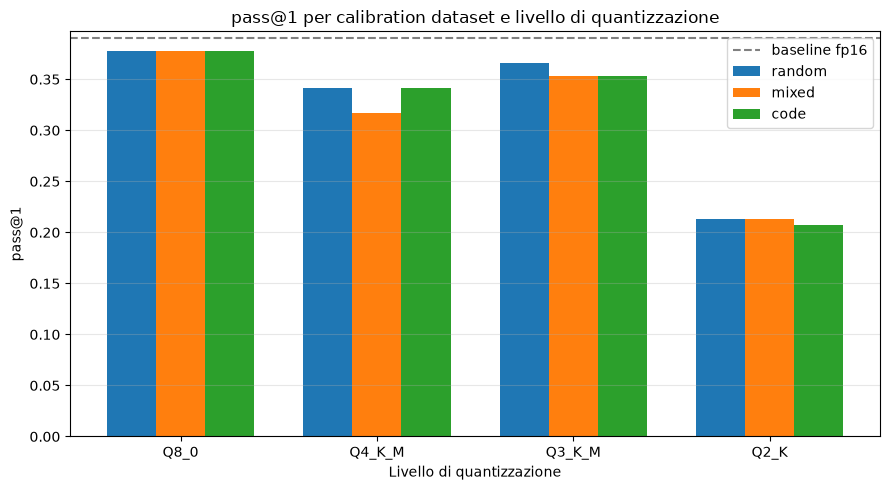

Grafico salvato in: ../results/figures/pass_at_1_grouped_bars.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

x = range(len(QUANT_LEVELS))
bar_width = 0.25

for i, calib in enumerate(CALIBRATIONS):
    y_values = [pivot.loc[calib, level] for level in QUANT_LEVELS]
    offsets = [xi + (i - 1) * bar_width for xi in x]
    ax.bar(offsets, y_values, width=bar_width, label=calib, color=colors[calib])

ax.axhline(baseline_pass1, color="gray", linestyle="--", linewidth=1.5, label="baseline fp16")

ax.set_xticks(list(x))
ax.set_xticklabels(QUANT_LEVELS)
ax.set_xlabel("Livello di quantizzazione")
ax.set_ylabel("pass@1")
ax.set_title("pass@1 per calibration dataset e livello di quantizzazione")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
fig_path_bar = f"{FIGURES_DIR}/pass_at_1_grouped_bars.png"
plt.savefig(fig_path_bar, dpi=150)
plt.show()

print(f"Grafico salvato in: {fig_path_bar}")

## 6. Classifica delle calibration a ciascun livello

Per rispondere direttamente alla domanda di ricerca: a ciascun livello di bit, quale calibration
dataset ottiene il pass@1 più alto?

In [7]:
print(f"{'Livello':<10} {'Migliore':<10} {'pass@1':<10} Classifica completa")
print("-" * 60)

for level in QUANT_LEVELS:
    scores = {calib: pivot.loc[calib, level] for calib in CALIBRATIONS}
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    best_calib, best_score = ranked[0]
    ranking_str = " > ".join([f"{c} ({s:.3f})" for c, s in ranked])
    print(f"{level:<10} {best_calib:<10} {best_score:<10.4f} {ranking_str}")

Livello    Migliore   pass@1     Classifica completa
------------------------------------------------------------
Q8_0       random     0.3780     random (0.378) > mixed (0.378) > code (0.378)
Q4_K_M     random     0.3415     random (0.341) > code (0.341) > mixed (0.317)
Q3_K_M     random     0.3659     random (0.366) > mixed (0.354) > code (0.354)
Q2_K       random     0.2134     random (0.213) > mixed (0.213) > code (0.207)
